# Finite Element Method in 1D/2D

We solve $-u''(x)=f(x)$ on $(0,1)$ with homogeneous Dirichlet boundaries and compare six mesh resolutions to show convergence.


## Weak form and discretization sweep


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/fem-1d-2d"); OUT.mkdir(parents=True, exist_ok=True)
f = lambda x: np.pi**2 * np.sin(np.pi*x)
u_true = lambda x: np.sin(np.pi*x)
levels = [16, 24, 36, 52, 74, 104]
sol = []
errs = []
for n in levels:
    x = np.linspace(0, 1, n+1)
    h = x[1]-x[0]
    N = n-1
    K = np.zeros((N, N)); b = np.zeros(N)
    for e in range(n):
        xL, xR = x[e], x[e+1]
        Ke = (1/h)*np.array([[1,-1],[-1,1]])
        xm = 0.5*(xL+xR); fe = f(xm)*h*0.5*np.array([1,1])
        idx = [e-1, e]
        for a in range(2):
            ia = idx[a]
            if 0 <= ia < N:
                b[ia] += fe[a]
                for c in range(2):
                    ic = idx[c]
                    if 0 <= ic < N:
                        K[ia, ic] += Ke[a, c]
    u_int = np.linalg.solve(K, b)
    u = np.zeros(n+1); u[1:-1] = u_int
    sol.append((x, u))
    errs.append(np.max(np.abs(u - u_true(x))))


## Six discretization levels


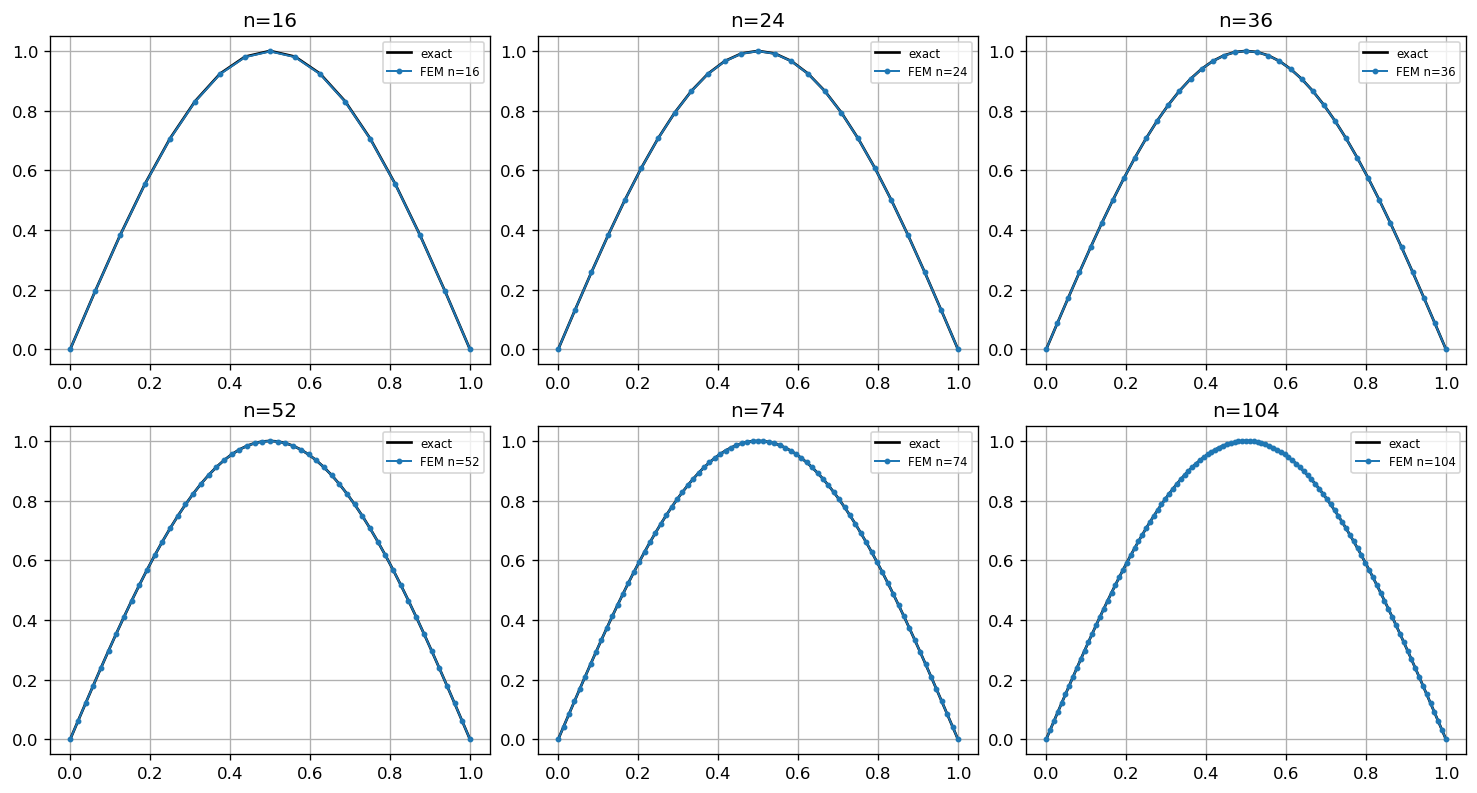

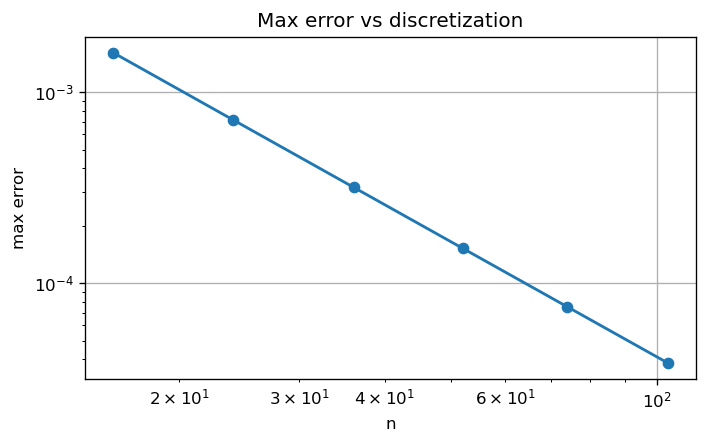

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(12.2, 6.5), constrained_layout=True)
for ax, (n, (x, u)) in zip(axes.ravel(), zip(levels, sol)):
    ax.plot(x, u_true(x), "k", lw=1.6, label="exact")
    ax.plot(x, u, "o-", ms=2.5, lw=1.2, label=f"FEM n={n}")
    ax.set_title(f"n={n}")
    ax.legend(fontsize=7)
plt.figure(figsize=(6, 3.8))
plt.loglog(levels, errs, "o-", lw=1.7)
plt.title("Max error vs discretization")
plt.xlabel("n")
plt.ylabel("max error")
plt.tight_layout()
plt.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
